# Results Analysis & Thesis Figures
### Master's Research: Machine Unlearning — Multi-Class Image Classification
**Author:** Mikołaj Hajder 264478

This notebook is **read-only with respect to training** — it only loads saved checkpoints and produces plots.  
All heavy computation (training, unlearning) is done by the CLI scripts via `colab_runner_kaggle.ipynb`:
- `train.py`
- `unlearn_naive.py`

> **Before running:** make sure you have run `colab_runner_kaggle.ipynb` at least once  
> so that checkpoints exist in `/kaggle/working/checkpoints/`.


## 0. Configuration — set paths here
Paths are pre-configured for Kaggle. Uncomment the relevant block below if running locally or on Colab.


In [1]:
import os, sys

# ── Kaggle paths ────────────────────────────────────────────────────
# CKPT_DIR  = '/kaggle/working/checkpoints'
# DATA_ROOT = '/kaggle/working/data'

# ── Local paths (uncomment when running locally) ────────────────────
CKPT_DIR  = '../checkpoints'
DATA_ROOT = '../data'

# ── Colab + Google Drive (uncomment when running on Colab) ──────────
# CKPT_DIR  = '/content/drive/MyDrive/master_thesis/checkpoints'
# DATA_ROOT = '/content/drive/MyDrive/master_thesis/data'

DATASET     = 'CIFAR10'       # 'CIFAR10' | 'CIFAR100'
NUM_CLASSES = 10 if DATASET == 'CIFAR10' else 100

# Add repo root to path
sys.path.insert(0, '/kaggle/working/master_thesis')

print(f'Checkpoint dir : {os.path.abspath(CKPT_DIR)}')
print(f'Dataset        : {DATASET}')


Checkpoint dir : /home/okejka/PycharmProjects/master_thesis/checkpoints
Dataset        : CIFAR10


## 1. Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from utils import (STATS, evaluate, get_datasets, get_test_transform,
                   load_checkpoint, per_class_accuracy)

plt.rcParams.update({
    'figure.dpi':     120,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'font.size':          11,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cpu


## 2. Load Checkpoints

In [3]:
ds_tag = DATASET.lower()

original_ckpt     = os.path.join(CKPT_DIR, f'resnet18_{ds_tag}_best.pth')
naive_unlearn_ckpt = os.path.join(CKPT_DIR, f'resnet18_{ds_tag}_naive_unlearn_best.pth')

print('Loading original model...')
original_model = load_checkpoint(original_ckpt, device)
orig_ckpt_data  = torch.load(original_ckpt, map_location='cpu')
orig_history    = orig_ckpt_data.get('history', {})

naive_model = None
naive_history = {}
naive_cfg = {}

if os.path.exists(naive_unlearn_ckpt):
    print('\nLoading naive unlearned model...')
    naive_model = load_checkpoint(naive_unlearn_ckpt, device)
    naive_ckpt_data = torch.load(naive_unlearn_ckpt, map_location='cpu')
    naive_history   = naive_ckpt_data.get('history', {})
    naive_cfg       = naive_ckpt_data.get('config',  {})
    
    forget_strategy = naive_cfg.get('forget_strategy', 'unknown')
    forget_size     = naive_ckpt_data.get('forget_size', '?')
    retain_size     = naive_ckpt_data.get('retain_size', '?')
    print(f'\nForget strategy : {forget_strategy}')
    print(f'Forget set size : {forget_size}')
    print(f'Retain set size : {retain_size}')
else:
    print('\nNo naive unlearned model found. Only evaluating original model.')
    # Provide default config values so the split building doesn't crash
    naive_cfg = {'seed': 42, 'forget_strategy': 'random', 'forget_fraction': 0.01, 'batch_size': 256}
    forget_strategy = 'random'
    forget_size, retain_size = '?', '?'


Loading original model...
Loaded  : ../checkpoints/resnet18_cifar10_best.pth
Dataset : CIFAR10  |  Epoch: 97  |  Test acc: 94.79%

No naive unlearned model found. Only evaluating original model.


## 3. Build Data Splits

In [4]:
import random, torchvision

full_train, test_ds = get_datasets(DATASET, DATA_ROOT)
DatasetClass = (torchvision.datasets.CIFAR10 if DATASET == 'CIFAR10'
                else torchvision.datasets.CIFAR100)
full_eval = DatasetClass(root=DATA_ROOT, train=True, download=True,
                         transform=get_test_transform(DATASET))

# Reconstruct forget / retain split using same seed as unlearning script
seed = naive_cfg.get('seed', 42)
rng  = random.Random(seed)
all_indices = list(range(len(full_train)))

if forget_strategy == 'random':
    frac = naive_cfg.get('forget_fraction', 0.01)
    forget_indices = rng.sample(all_indices, int(len(all_indices) * frac))
elif forget_strategy == 'class':
    cls = naive_cfg.get('forget_class', 0)
    forget_indices = [i for i, (_, label) in enumerate(full_train) if label == cls]

forget_set     = set(forget_indices)
retain_indices = [i for i in all_indices if i not in forget_set]

bs = naive_cfg.get('batch_size', 256)
retain_eval_loader = DataLoader(Subset(full_eval, retain_indices),
                                batch_size=bs, shuffle=False, num_workers=2)
forget_loader      = DataLoader(Subset(full_eval, forget_indices),
                                batch_size=bs, shuffle=False, num_workers=2)
test_loader        = DataLoader(test_ds, batch_size=bs, shuffle=False, num_workers=2)

print(f'Forget : {len(forget_indices):,}  |  Retain : {len(retain_indices):,}  |  Test : {len(test_ds):,}')


Forget : 500  |  Retain : 49,500  |  Test : 10,000


## 4. Evaluation — All Splits

In [5]:
criterion = nn.CrossEntropyLoss()

orig_retain_loss, orig_retain_acc = evaluate(original_model, retain_eval_loader, criterion, device)
orig_forget_loss, orig_forget_acc = evaluate(original_model, forget_loader,      criterion, device)
orig_test_loss,   orig_test_acc   = evaluate(original_model, test_loader,        criterion, device)

print(f"{'='*62}")
print(f"{'Metric':<20} {'Original':>12}")
print(f"{'='*62}")
print(f"{'Retain Accuracy':<20} {orig_retain_acc:>11.2f}%")
print(f"{'Forget Accuracy':<20} {orig_forget_acc:>11.2f}%")
print(f"{'Test Accuracy':<20} {orig_test_acc:>11.2f}%")

if naive_model is not None:
    naive_retain_loss, naive_retain_acc = evaluate(naive_model, retain_eval_loader, criterion, device)
    naive_forget_loss, naive_forget_acc = evaluate(naive_model, forget_loader,      criterion, device)
    naive_test_loss,   naive_test_acc   = evaluate(naive_model, test_loader,        criterion, device)

    print(f"\n{'='*62}")
    print(f"{'Metric':<20} {'Original':>12}  {'Naive Retrain':>14}  {'Δ':>6}")
    print(f"{'='*62}")
    rows = [
        ('Retain Accuracy', orig_retain_acc, naive_retain_acc),
        ('Forget Accuracy', orig_forget_acc, naive_forget_acc),
        ('Test Accuracy',   orig_test_acc,   naive_test_acc),
    ]
    for name, orig, naive in rows:
        delta = naive - orig
        sign  = '+' if delta >= 0 else ''
        print(f'{name:<20} {orig:>11.2f}%  {naive:>13.2f}%  {sign}{delta:>5.2f}%')
print(f"{'='*62}")


Metric                   Original
Retain Accuracy            99.99%
Forget Accuracy           100.00%
Test Accuracy              94.79%


## 5. Training Curves

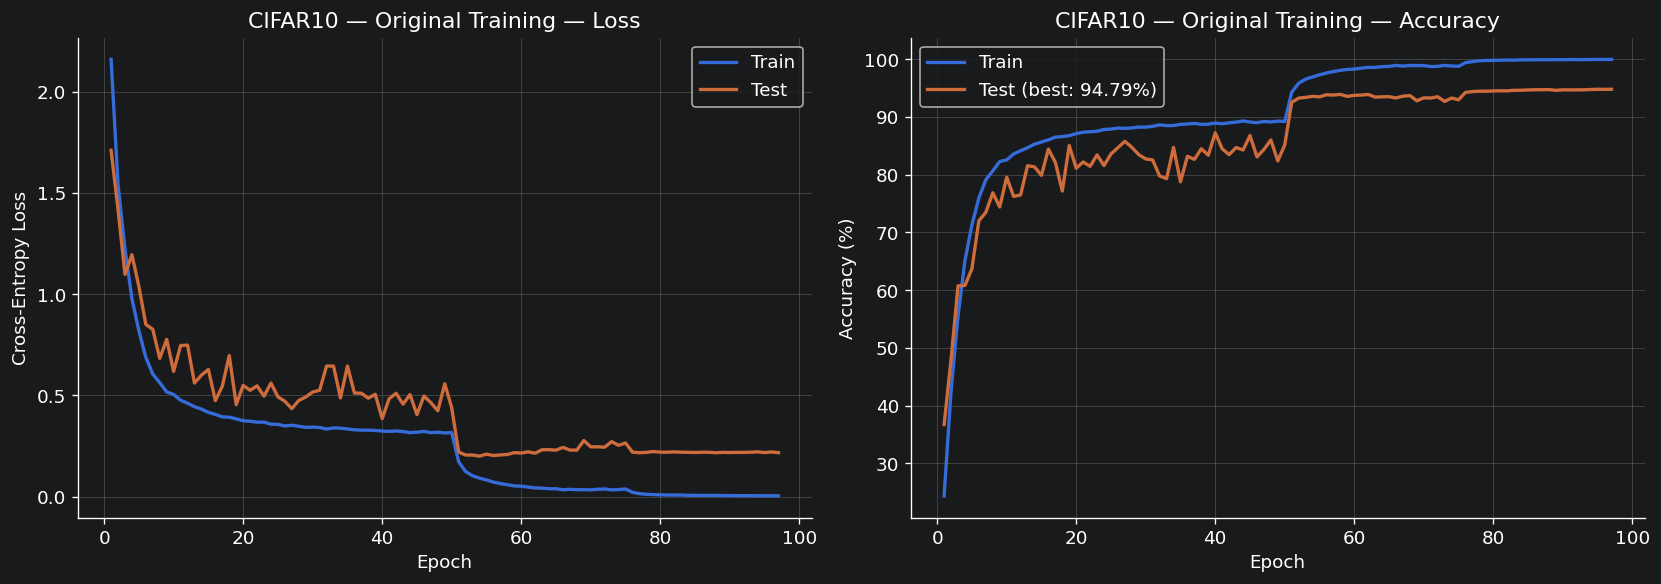

In [6]:
def plot_curves(history, title, best_acc=None):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(epochs, history['test_loss'],  label='Test',  linewidth=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    best_label = f'Test (best: {best_acc:.2f}%)' if best_acc else 'Test'
    axes[1].plot(epochs, history['train_acc'], label='Train',      linewidth=2)
    axes[1].plot(epochs, history['test_acc'],  label=best_label,   linewidth=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    return fig

if orig_history:
    fig = plot_curves(orig_history, f'{DATASET} — Original Training',
                      best_acc=orig_ckpt_data.get('test_acc'))
    fig.savefig(os.path.join(CKPT_DIR, f'resnet18_{ds_tag}_training_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No training history found in original checkpoint.')


In [ ]:
if naive_history:
    fig = plot_curves(naive_history,
                      f'{DATASET} — Naive Unlearning ({forget_strategy}, {forget_size} samples)',
                      best_acc=naive_ckpt_data.get('test_acc'))
    fig.savefig(os.path.join(CKPT_DIR, f'resnet18_{ds_tag}_naive_unlearn_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No training history found in naive checkpoint.')


## 6. Per-Class Accuracy

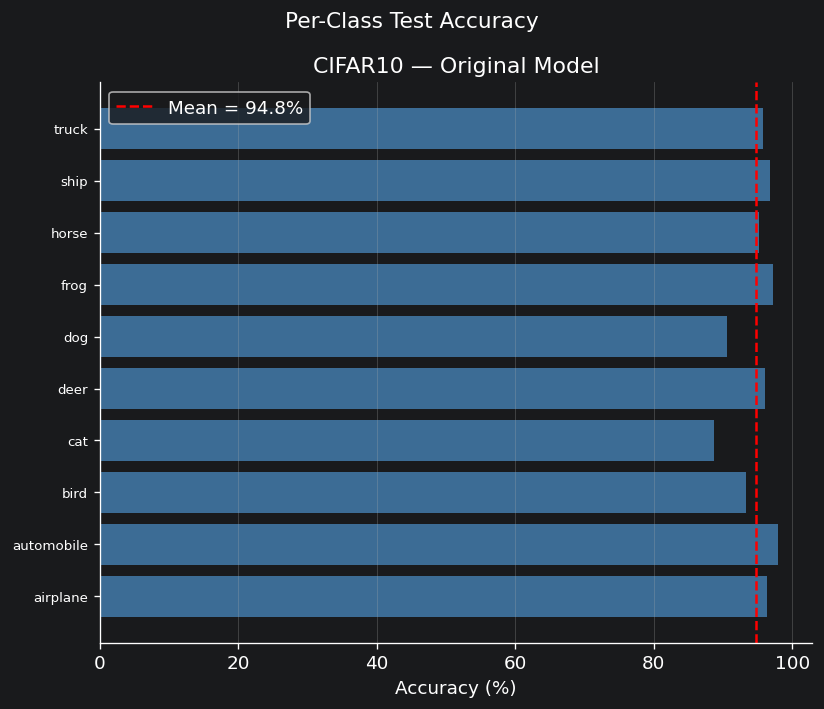

In [7]:
orig_per_class = per_class_accuracy(original_model, test_loader, NUM_CLASSES, device)
classes        = full_train.classes

if naive_model is not None:
    naive_per_class = per_class_accuracy(naive_model, test_loader, NUM_CLASSES, device)
    fig_h = max(6, NUM_CLASSES * 0.25)
    fig, axes = plt.subplots(1, 2, figsize=(14, fig_h), sharey=True)
    plots = [(axes[0], orig_per_class.numpy(), 'Original Model'),
             (axes[1], naive_per_class.numpy(), 'Naive Unlearned Model')]
else:
    fig_h = max(6, NUM_CLASSES * 0.25)
    fig, axes = plt.subplots(1, 1, figsize=(7, fig_h))
    plots = [(axes, orig_per_class.numpy(), 'Original Model')]

y_pos = np.arange(NUM_CLASSES)
for ax, values, title in plots:
    ax.barh(y_pos, values, align='center', color='steelblue', alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(classes, fontsize=8)
    ax.set_xlabel('Accuracy (%)')
    ax.set_title(f'{DATASET} — {title}')
    ax.axvline(x=values.mean(), color='red', linestyle='--',
               label=f'Mean = {values.mean():.1f}%')
    ax.legend(); ax.grid(axis='x', alpha=0.3)

plt.suptitle('Per-Class Test Accuracy', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(CKPT_DIR, f'resnet18_{ds_tag}_per_class_acc.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## 7. Forget-Set Confidence Visualisation
A well-unlearned model should show **lower, more uniform** confidence on forget samples.

In [ ]:
mean_t = torch.tensor(STATS[DATASET]['mean']).view(3, 1, 1)
std_t  = torch.tensor(STATS[DATASET]['std']).view(3, 1, 1)

def denorm(img_tensor):
    return (img_tensor * std_t + mean_t).permute(1, 2, 0).numpy().clip(0, 1)

@torch.no_grad()
def get_confidences(model, loader, n=16):
    model.eval()
    imgs, trues, preds, confs = [], [], [], []
    for images, labels in loader:
        probs = torch.softmax(model(images.to(device)), dim=1)
        c, p  = probs.max(dim=1)
        imgs.append(images.cpu()); trues.append(labels)
        preds.append(p.cpu());     confs.append(c.cpu())
        if sum(len(x) for x in trues) >= n:
            break
    return [torch.cat(x)[:n] for x in [imgs, trues, preds, confs]]

N_VIS = 8
orig_imgs, orig_true, orig_pred, orig_conf = get_confidences(original_model, forget_loader, N_VIS)
naive_imgs, naive_true, naive_pred, naive_conf = get_confidences(naive_model,  forget_loader, N_VIS)

fig, axes = plt.subplots(2, N_VIS, figsize=(N_VIS * 2, 5))
for i in range(N_VIS):
    for row, (imgs, pred, conf, label) in enumerate([
        (orig_imgs,  orig_pred,  orig_conf,  'Orig'),
        (naive_imgs, naive_pred, naive_conf, 'Naive'),
    ]):
        axes[row, i].imshow(denorm(imgs[i]))
        color = 'green' if pred[i] == orig_true[i] else 'red'
        axes[row, i].set_title(
            f'{label}\n{classes[pred[i]]}\n{conf[i]*100:.0f}%',
            fontsize=7, color=color)
        axes[row, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Naive',    fontsize=9)
plt.suptitle(f'Forget-Set Predictions ({DATASET})', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(CKPT_DIR, f'resnet18_{ds_tag}_forget_confidence.png'),
            dpi=150, bbox_inches='tight')
plt.show()
